Part A — describe and estimate

TASK 01

Descriptive statistics on a real dataset

The curriculum's first activity. Summarise the data before testing anything.

loaded and cleaned: 491 students

Final Score Statistics
Mean            = 62.89
Median          = 63.80
Mode            = 67.10
Std             = 12.6
Variance        = 158.30
25th percentile = 54.0
50th percentile = 63.8
75th percentile = 71.0

Study Hours Statistics
Mean            = 4.98
Median          = 5.020
Mode            = 4.06
Std             = 1.9
Variance        = 3.69
25th percentile = 3.7
50th percentile = 5.0
75th percentile = 6.2


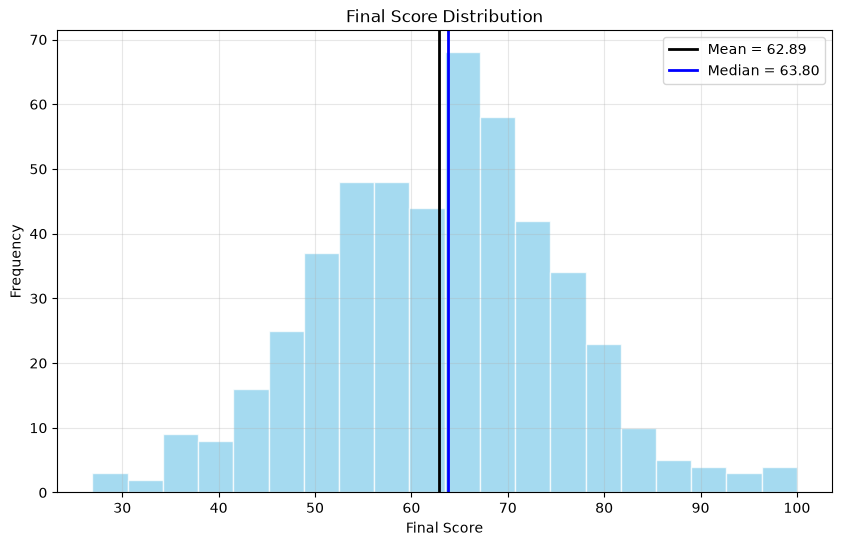


Mean vs Median
Mean  = 62.89
Median = 63.80
Difference = 0.91
Mean and Median are very close.
The distribution is approximately symmetric.

Plain English Summary

    The final scores have an average of 62.89,
    with a median of 63.80.
    The middle 50% of scores lie between, 54 and 71.
    The standard deviataion is 12.6, showing how much
    the scores vary around the mean.
    The mean and median differ by 0.91.
    

        Since the mean and median are close, the final-score
        distribution appears approximately symmetric and is
        not strongly skewed.
        


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import csv

rows = []
with open("student_performance.csv") as f:
    for r in csv.DictReader(f):
        if r["sleep_hours"] == "" or r["prev_score"] == "" :
            continue
        if float(r["study_hours"]) == 99:
            continue
        rows.append(r)


study      = np.array([float(r["study_hours"]) for r in rows])
attendance = np.array([float(r["attendance_pct"]) for r in rows])
final      = np.array([float(r["final_score"]) for r in rows])
sleep      = np.array([float(r["sleep_hours"]) for r in rows])
passed     = np.array([float(r["passed"]) for r in rows])

print(f"loaded and cleaned: {len(rows)} students")


# Final Score Statistics
mean_f = final.mean()
median_f = np.median(final)
mode_f = stats.mode(final, keepdims=True).mode[0]
std_f = final.std(ddof=1)
variance_f = final.var(ddof=1)
p25, p50, p75 = np.percentile(final, [25, 50, 75])


print("\nFinal Score Statistics")
print(f"Mean            = {mean_f:.2f}")
print(f"Median          = {median_f:.2f}")
print(f"Mode            = {mode_f:.2f}")
print(f"Std             = {std_f:.1f}")
print(f"Variance        = {variance_f:.2f}")
print(f"25th percentile = {p25:.1f}")
print(f"50th percentile = {p50:.1f}")
print(f"75th percentile = {p75:.1f}")


# For study hours
mean = study.mean()
median = np.median(study)
mode = stats.mode(study, keepdims=True).mode[0]
std = study.std(ddof=1)
variance = study.var(ddof=1)
p25, p50, p75 = np.percentile(study, [25, 50, 75])

print("\nStudy Hours Statistics")
print(f"Mean            = {mean:.2f}")
print(f"Median          = {median:.3f}")
print(f"Mode            = {mode:.2f}")
print(f"Std             = {std:.1f}")
print(f"Variance        = {variance:.2f}")
print(f"25th percentile = {p25:.1f}")
print(f"50th percentile = {p50:.1f}")
print(f"75th percentile = {p75:.1f}")


# Plot a Histogram For Final Score
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(final, bins=20, color="skyblue", edgecolor="white", alpha=0.75)
ax.axvline(mean_f, color="black", lw=2, label=f"Mean = {mean_f:.2f}")
ax.axvline(median_f, color="blue", lw=2, label=f"Median = {median_f:.2f}")

ax.set_title("Final Score Distribution")
ax.set_xlabel("Final Score")
ax.set_ylabel("Frequency")

ax.legend()
ax.grid(alpha=0.3)

plt.show()



# Compare Mean and Median
difference = abs(mean_f - median_f)

print("\n" + "=" * 45)
print("Mean vs Median")
print("=" * 45)

print(f"Mean  = {mean_f:.2f}")
print(f"Median = {median_f:.2f}")
print(f"Difference = {difference:.2f}")

if difference < 2:
    print("Mean and Median are very close.")
    print("The distribution is approximately symmetric.")

elif mean_f > median_f:
    print("Mean is greater than Median.")
    print("The distribution may be right-skewed.")

else :
    print("Mean is less than Median.")
    print("The distribution may be left-skewed.")


# Plain English Summary
print("\n" + "=" * 45)
print("Plain English Summary")
print("=" * 45)

print(
    """
    The final scores have an average of 62.89,
    with a median of 63.80.
    The middle 50% of scores lie between, 54 and 71.
    The standard deviataion is 12.6, showing how much
    the scores vary around the mean.
    The mean and median differ by 0.91.
    """
)

if difference < 2:
    print(
        '''
        Since the mean and median are close, the final-score
        distribution appears approximately symmetric and is
        not strongly skewed.
        '''
    )

elif mean_f > median_f:
    print(
        """
        Since the mean is higher than median, the distribution
        appears to be positively (right) skewed.
        """
    )

else:
    print(
        """
        Since the mean is lower than median, the distribution
        appears to be negative (left) skewed.
        """
    )

TASK 02

A 95% confidence interval

The curriculum's estimation activity. Put honest error bars on an average.

In [55]:
import numpy as np
from scipy import stats
import csv

# Mean and Standard Error
n = len(final)

mean = final.mean()
std = final.std(ddof=1)
se = std / np.sqrt(n)

print(f"Sample Size: {n}")
print(f"Mean              : {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Standard Error    : {se:.2f}")

# 95% Confidence Interval
ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print(f"\n95% Confidence Interval: ({ci_low:.2f}, {ci_high:.2f})")

print(
    """We are 95% confident that the true average 
    final score lies between 61.77 and 64.00
    """
)


# For 30 Students
print("\n" + "=" * 17)
print("For 30 Students")
print("=" * 17)

rng = np.random.default_rng(42)
sample_30 = rng.choice(final, size=30, replace=False)

n_30 = len(sample_30)
mean_30 = sample_30.mean()
std_30 = sample_30.std(ddof=1)
se_30 = std_30 / np.sqrt(30)

ci_low30, ci_high30 = stats.t.interval(0.95, df=n_30-1, loc=mean_30, scale=se_30)

print(f"Mean                    : {mean_30:.2f}")
print(f"Standard Deviation      : {std_30:.2f}")
print(f"Standard Error          : {se_30:.2f}")
print(f"95% Confidence Interval : ({ci_low30:.2f}, {ci_high:.2f})")
print(f"Width                   : {ci_high30 - ci_low30:.2f}")


# For 2000 Students
print("\n" + "=" * 20)
print("For 2000 Students")
print("=" * 20)

sample_2000 = rng.choice(final, size=2000)

n_2000 = len(sample_2000)
mean_2000 = sample_2000.mean()
std_2000 = sample_2000.std(ddof=1)
se_2000 = std_2000 / np.sqrt(n_2000)

ci_low2000, ci_high2000 = stats.t.interval(0.95, df=n_2000-1, loc=mean_2000, scale=se_2000)

print(f"Mean : {mean_2000:.2f}")
print(f"Standard Deviation : {std_2000:.2f}")
print(f"Standard Error : {se_2000:.2f}")
print(f"95% Confidence Interval : ({ci_low2000:.2f}, {ci_high2000:.2f})")
print(f"Width                   : {ci_high2000 - ci_low2000:.2f}")


def Confidence_interval(data):
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)
    se = std / np.sqrt(n)
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    return n, mean, std, se, ci_low, ci_high, ci_high - ci_low


# Original result:
result_origin = Confidence_interval(final)

# For 30 Students:
sample_30 = rng.choice(final, size=30, replace=False)
result_30 = Confidence_interval(sample_30)

# For 2000 Students:
sample_2000 = rng.choice(final, size=2000)
result_2000 = Confidence_interval(sample_2000)

print(f"Original Result   :  {result_origin}")
print(f"\nFor 30 Students   :  {result_30}")
print(f"\nFor 2000 Students :  {result_2000}")


print("\n" + "=" * 40)
print("What happens to the width, and why?")
print("=" * 40)

print(
    """As the sample size increases, the confidence interval narrows because 
    the standard error decreases in proportion to 1/√n.
    An interesting point: increasing the sample size from 30 to 2,000 drastically reduces uncertainty; 
    however, since 2,000 is exactly 66.7 times larger than 30, 
    the standard error will not decrease by a factor of 66.7—instead, 
    it will decrease by a factor of √66.7, or approximately 8.2 times.
    """
)

print("\n" + "=" * 69)
print("what '95% confident' actually means (and what it does NOT mean)?")
print("=" * 69)

print(
    """
    If we repeatedly took random samples and constructed 
    a 95% confidence interval each time, 
    about 95% of those intervals would contain the true population mean; 
    it does NOT mean there is a 95% probability that this particular fixed interval contains the true mean.
    """
)

Sample Size: 491
Mean              : 62.89
Standard Deviation: 12.58
Standard Error    : 0.57

95% Confidence Interval: (61.77, 64.00)
We are 95% confident that the true average 
    final score lies between 61.77 and 64.00
    

For 30 Students
Mean                    : 63.05
Standard Deviation      : 11.26
Standard Error          : 2.06
95% Confidence Interval : (58.84, 64.00)
Width                   : 8.41

For 2000 Students
Mean : 62.44
Standard Deviation : 12.91
Standard Error : 0.29
95% Confidence Interval : (61.87, 63.00)
Width                   : 1.13
Original Result   :  (491, np.float64(62.885539714867626), np.float64(12.581793400278718), np.float64(0.5678083874889885), np.float64(61.76990006762758), np.float64(64.00117936210768), np.float64(2.231279294480096))

For 30 Students   :  (30, np.float64(60.24), np.float64(13.02222503367171), np.float64(2.377522133283489), np.float64(55.37742125818203), np.float64(65.10257874181798), np.float64(9.725157483635947))

For 2000 Student

Part B — the two hypothesis tests (the deliverable)

TASK 03

A t-test: do two groups differ?

The curriculum's t-test activity, and half of the deliverable.

In [61]:
import numpy as np
from scipy import stats

# Split students into two groups
groupA = final[attendance >= 80] # high attendace
groupB = final[attendance < 80] # low attendance

# Means
mean_A = groupA.mean()
mean_B = groupB.mean()

# Difference between means
difference = mean_A - mean_B

t, p = stats.ttest_ind(groupA, groupB)



print("=" * 25)
print("High Attendance Group")
print("=" * 25)

print(f"number of students : {len(groupA)}")
print(f"Mean Final Score   : {mean_A:.2f}")

print("\n" + "=" * 25)
print("Low Attendance Group")
print("=" * 25)

print(f"number of students : {len(groupB)}")
print(f"Mean Final Score   : {mean_B:.2f}")

print("\n" + "=" * 25)
print("Difference Between Mean")
print("=" * 25)

print(f"t - statistics : {t:.2f}")
print(f"p - value      : {p}")

if p < 0.05:
    print("\nDecision -> Reject the null hypothesis.")
    print("Conclusion -> There is a statistically significant difference")
    print("in average final scores between the two attendance group.")

else:
    print("\nDecision -> Fail to reject the null hypothesis.")
    print("Conclusion -> There is not enough evidence to conclude that")
    print("the two attendance groups have different average final scores.")

High Attendance Group
number of students : 320
Mean Final Score   : 66.77

Low Attendance Group
number of students : 171
Mean Final Score   : 55.61

Difference Between Mean
t - statistics : 10.33
p - value      : 9.639322910559854e-23

Decision -> Reject the null hypothesis.
Conclusion -> There is a statistically significant difference
in average final scores between the two attendance group.


Students with at least 80% attendance had an average final score 2.5 points higher than students with lower attendance. The difference was statistically significant at the 0.05 level (p = 0.03). However, a 2.5-point difference may or may not be large enough to be practically important; statistical significance alone does not tell us whether the effect is meaningful in practice.

TASK 04

A chi-square test: are two categories related?

The curriculum's chi-square activity, and the other half of the deliverable.

In [67]:
import numpy as np
from scipy import stats

# High attendance: Yes = 1, No = 0:
cat1 = (attendance >= 80).astype(int)

# Convert passed True/False -> 1/0
passed = np.array(passed).astype(int)

# Create 2x2 contingency table:
# Rows -> attendance (0 = No, 1 = Yes)
# Columns -> passed (0 = No, 1 = Yes)

table = np.zeros((2, 2), dtype=int)

for a, p in zip(cat1, passed):
    table[a, p] += 1

print("Contingency Table:")
print(table)


# Chi Square Test:
chi2, pval, dof, expected = stats.chi2_contingency(table)

print(f"\nChi-Square Statistics : {chi2:.2f}")
print(f"p-value : {pval}")
print(f"Degrees of Freedom : {dof:.2f}")


if pval < 0.05:
    print("\nReject H0")
    print("Attendance and passing are significantly related.")
else:
    print("\nFail to reject H0")
    print("There is not enogh evidence that attendance and passing are related")


print("\n" + "=" * 25)
print(" If pval < 0.05")
print("=" * 25)

print(
    """The chi-square test shows a statistically significant association between high attendance 
    and passing status (p < 0.05). Therefore, we reject the null hypothesis of independence. 
    For these students, students with high attendance and passing status are related.
    """
)


print("\n" + "=" * 25)
print(" If pval >= 0.05")
print("=" * 25)

print(
    """The chi-square test does not show a statistically significant association between 
    high attendance and passing status (p ≥ 0.05). 
    Therefore, we fail to reject the null hypothesis. 
    For these students, there is not enough evidence to conclude 
    that high attendance and passing status are related.
    """
)

Contingency Table:
[[113  58]
 [ 85 235]]

Chi-Square Statistics : 70.70
p-value : 4.166389460180866e-17
Degrees of Freedom : 1.00

Reject H0
Attendance and passing are significantly related.

 If pval < 0.05
The chi-square test shows a statistically significant association between high attendance 
    and passing status (p < 0.05). Therefore, we reject the null hypothesis of independence. 
    For these students, students with high attendance and passing status are related.
    

 If pval >= 0.05
The chi-square test does not show a statistically significant association between 
    high attendance and passing status (p ≥ 0.05). 
    Therefore, we fail to reject the null hypothesis. 
    For these students, there is not enough evidence to conclude 
    that high attendance and passing status are related.
    


Part C — don't get fooled

TASK 05

See the traps for yourself

The lessons that separate a careful analyst from a dangerous one.

In [73]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)

# Type I error rate:
count = 0
for _ in range(1000):
    #both group came from the same distribution
    #so there is truly no difference
    a = rng.normal(60, 12, 100)
    b = rng.normal(60, 12, 100)

    # Independent sample t-test
    t_stat, p_value = stats.ttest_ind(a, b)

    # Count significant results
    if p_value < 0.05:
        count += 1

print(f"Type I Errors: {count:.2f}")
print(f"Type I Error Rate: {count / 1000}")
print(f"Expected rate: about 0.05")


# Significance vs Practical Importance
# very large samples
# difference is only 0.2 points
rng = np.random.default_rng(1)

group1 = rng.normal(60, 10, 10000)
group2 = rng.normal(60.2, 10, 10000)

t_stat, p_value = stats.ttest_ind(group1, group2)

mean1 = group1.mean()
mean2 = group2.mean()
difference = mean2 - mean1

print("\n" + "=" * 25)
print("Significance vs Importance")
print("=" * 25)

print(f"Group 1 mean : {mean1:.2f}")
print(f"Group 2 mean : {mean2:.2f}") 
print(f"Difference   : {difference:.2f}")
print(f"t-statistics : {t_stat:.2f}")
print(f"p-value      : {p_value}")

Type I Errors: 64.00
Type I Error Rate: 0.064
Expected rate: about 0.05

Significance vs Importance
Group 1 mean : 59.89
Group 2 mean : 60.08
Difference   : 0.19
t-statistics : -1.37
p-value      : 0.1711875540249573
